## Distogram Prediction using DistFormer model

In this notebook, we demonstrate how to predict distogram using DistFormer

In [1]:
%cd ..

/net/kihara/scratch/nibtehaz/Prot-LAMBDA


In [2]:
## Load model

from ProtLAMBDA import DistFormer, ProtLAMBDA, LambdaFold, load_fastas
import torch

plm = ProtLAMBDA()
plm.load_state_dict(torch.load('/net/kihara/scratch/nibtehaz/Prot-LAMBDA/params/ProtLAMBDA.pth',map_location='cpu'))
dst = DistFormer()
dst.load_state_dict(torch.load('/net/kihara/scratch/nibtehaz/Prot-LAMBDA/params/DistFormer.pth',map_location='cpu'))

dvc = 'cuda:3'

plm.to(dvc)
dst.to(dvc)
plm.eval()
dst.eval();

/tmp/ipykernel_1814452/21965962.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  plm.load_state_dict(torch.load('/net/kihara/scratch/nibtehaz/Prot-LAMBDA/params/ProtLAMBD

In [3]:
## Load seqs 

from ProtLAMBDA import load_fastas

seqs = load_fastas('sample_protein')

seqs

[['7fjs_L',
  'RTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGECQIVLTQSPSSLAVSVGEKVTLSCKSSQSLLYSNNQKNYLAWYQQKSGRSPKLLLHWTSTRESGVPDRFTGSGSGTDFTLTISSVKAEDLAVYYCQQYYTYPWTFGGGTKLEIKRTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC'],
 ['7x8v_A',
  'GPGHMMAAEAWRSRFRERVVEAAERWESVGESLATALTHLKSPMHAGDEEEAAAARTRIQLAMGELVDASRNLASAMSLMKVAELLALHGGSVNPSTHLGEISLLGDQYLAERNAGIKLLEAGKDARKAYISVDGCRGNLDAILLLLDHPRVPCVDDFIEEELFVAGDNLQGAIGNAKLGTERAVGARQDVSGAN'],
 ['T1089',
  'MDDNVNDFRPVPYPDEVVGLNPDPDFEPIWEIASPTITVFSSKASNDISYRVPAIAVTKKGSILVFCEARYGTWQDKAGRTDILMKRSTDKGITWTEKNLTNQATSSKLSYMDPTVVVDQVTGKIFLFTSLWDAVGKESAKQGYNNRAIMYTSEDDGLNWTRKDLTDEVEIGIFSGATRMIGSFGPGSGVQMTSSEQYKNRLIVPIRTFKVNEAAGTVSNGGNTAMWSDDNGGTWETGQPNKSGEWMVTEAPDGALIGNIRYNGHRQNYVSTDGGAKWPSFSDYDPIALPTPAKGCAGSVIVKDGWMYYCGAKGIIETTAHDDRGILYLAKAKFFGGHSHTFDPADHMVLYDKAAGYTCMALLPDGDMAIVAELGNEPGFQKLSTRPAEWMRLELFILSTKKPL'],
 ['T1034',
  'LILN

In [4]:
## considering only T1034 for now

seqs = [seqs[3]]

In [5]:
## pad sequences

for i in range(len(seqs)):
    seq = seqs[i][1]
    padding = 16 - len(seq)%16
    seqs[i][1] = seq+'<pad>'*padding

## compute plm representations

with torch.no_grad():
    seq_repr, pair_repr = plm.get_repr(seqs)

seq_repr = seq_repr[:,1:-1,:]
pair_repr = pair_repr[:,1:-1,1:-1,:]


## data preparation for DistFormer
from ProtLAMBDA.openfold.model.dataset.af2_util import residue_constants

aa_tokens = plm.esm2_backbone.batch_converter(seqs)[:,1:-1].to(seq_repr.device)
af2_aa_tokens = torch.Tensor([residue_constants.restype_order.get(residue_constants.tok_mapper[bb], residue_constants.restype_num) for bb in torch.flatten(aa_tokens)]).to(torch.long).reshape(aa_tokens.shape).to(aa_tokens.device)
valid_seq_masks = (aa_tokens!=1)*1

## predict distogram, ignore the other outputs for now
with torch.no_grad():
    dists, _, _ = dst(seq_repr, pair_repr, aa_tokens, af2_aa_tokens,mask=valid_seq_masks, return_all=True)

In [6]:
## distogram thresholding

for i in range(len(dists)):
    dists[i] = dists[i].cpu().numpy()
    dists[i] = dists[i][0,:len(seqs[0][1].replace('<pad>','')),:len(seqs[0][1].replace('<pad>','')),:]
    dists[i] = dists[i].argmax(axis=-1)


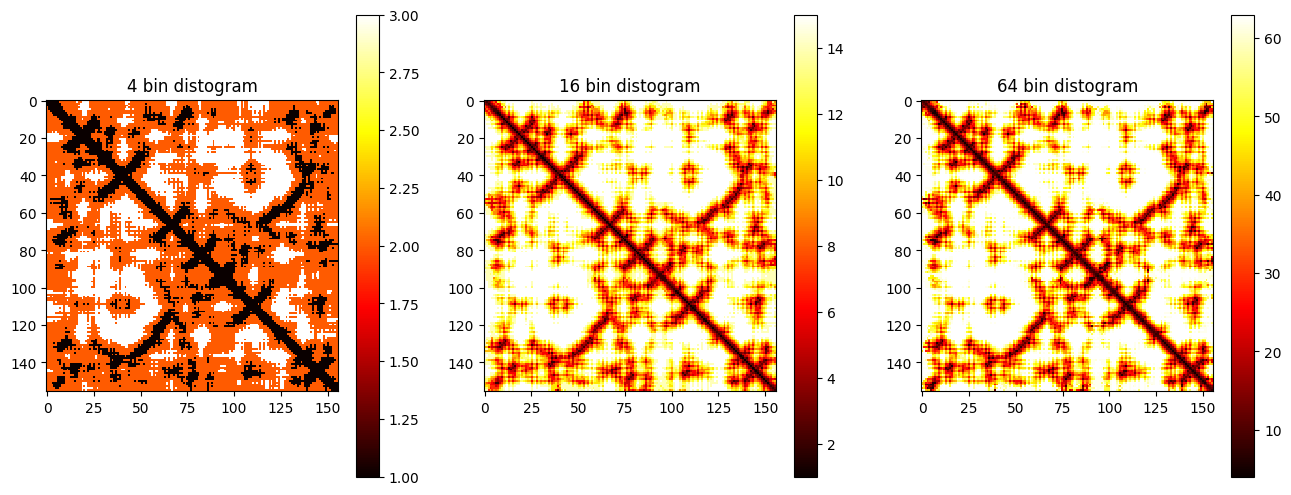

In [7]:
## plot distograms

import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.subplot(1,3,1)
plt.imshow(dists[0], cmap='hot', interpolation='nearest')
plt.title('4 bin distogram')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(dists[1], cmap='hot', interpolation='nearest')
plt.title('16 bin distogram')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(dists[2], cmap='hot', interpolation='nearest')
plt.title('64 bin distogram')
plt.colorbar();